In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
# Master Flight Operations Dataset
master_df = pd.read_csv("../data/final/flight_operations_master_dataset.csv")

# Weather Dataset
weather_df = pd.read_csv("../data/processed/weather/weather_feature_engineered.csv")

# Flight Delay Dataset
delay_df = pd.read_csv("../data/processed/delays/delays_feature_engineered.csv")

In [3]:
print(master_df.shape)
print(weather_df.shape)
print(delay_df.shape)

(7516, 72)
(1629108, 18)
(3000000, 41)


In [4]:
master_df.head()

,icao24,callsign,origin_country,time_position,last_constant,longitude,latitude,baro_altitude,on_ground,velocity,true_track,vertical_rate,geo_altitude,squawk,spi,position_source,flight_phase,speed_category,altitude_band,vertical_movement,heading_direction,operational_risk,N-NUMBER,SERIAL NUMBER,MFR MDL CODE,ENG MFR MDL,YEAR MFR,TYPE REGISTRANT,LAST ACTION DATE,CERT ISSUE DATE,CERTIFICATION,TYPE AIRCRAFT,TYPE ENGINE,STATUS CODE,MODE S CODE,AIR WORTH DATE,EXPIRATION DATE,UNIQUE ID,MODE S CODE HEX,MANUFACTURER,AIRCRAFT_MODEL,AIRCRAFT_TYPE_CODE,ENGINE_TYPE_CODE,AIRCRAFT_CATEGORY,BUILD_CERTIFICATE,NUMBER_OF_ENGINES,SEAT_CAPACITY,WEIGHT_CLASS,CRUISE_SPEED,TYPE_CERTIFICATE,CERTIFICATE_HOLDER,Aircraft_Age,Aircraft_Age_Category,Engine_Configuration,Seat_Capacity_Category,Weight_Category,Cruise_Speed_Category,Manufacturer_Group,Aircraft_Size_Category,distance_to_airport_km,nearest_ident,nearest_name,nearest_municipality,nearest_iso_country,nearest_airport_size,nearest_airport_category,nearest_airport_importance,nearest_latitude_deg,nearest_longitude_deg,nearest_lat_rad,nearest_lon_rad,datetime
0,80162D,AXB848,India,1.767745e+09,1767745048,52.7391,25.4425,9608.82,False,257.34,119.59,5.20,9829.80,3112.0,False,0,Climb,Cruise Speed,High Altitude,Climbing,East,Medium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115.199726,OMAS,Das Island Airport,Das Island,AE,Small,Local,Low,25.138234,52.874429,0.438745,0.922833,2026-01-07 00:17:28
1,AE1FA0,72209,United States,1.767745e+09,1767745047,-84.9380,38.1463,571.50,False,73.38,12.96,0.33,487.68,NaN,False,0,Cruise,Low Speed,Low Altitude,Level Flight,North,Low,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.518443,05KT,High Point Farm Airport,Frankfort,US,Small,Local,Low,38.187091,-84.930110,0.666490,-1.482310,2026-01-07 00:17:27
2,AC96B8,AAL1175,United States,1.767745e+09,1767745048,-102.0238,34.0962,10363.20,False,196.90,291.13,0.00,10683.24,NaN,False,0,Cruise,Cruise Speed,Cruise Altitude,Level Flight,West,Low,910AN,29512,13844CB,13802.0,1999.0,3.0,2023-10-20,1999-05-27,1T,5.0,5.0,V,53113270.0,1999-05-25,2030-04-30,927071.0,AC96B8,BOEING,737-823,5.0,5.0,1.0,0.0,2.0,162.0,CLASS 3,0.0,,...,27.0,Mid-Life,Twin Engine,Medium Commercial,Heavy,Unknown,Commercial,Narrow-Body,51.550924,1TX5,Laney Farm Airport,Hale Center,US,Small,Local,Low,34.126017,-101.908751,0.595611,-1.778643,2026-01-07 00:17:28
3,C81BD3,ZKAMK,New Zealand,1.767745e+09,1767744917,174.5408,-35.8060,624.84,False,56.90,165.34,0.65,670.56,NaN,False,0,Cruise,Low Speed,Low Altitude,Level Flight,South,Low,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.487628,NZ-0085,Tahere Airstrip,Whareora,NZ,Small,Local,Low,-35.696260,174.436410,-0.623017,3.044490,2026-01-07 00:15:17
4,AA56DB,UAL2447,United States,1.767745e+09,1767745048,-102.7402,37.4696,10972.80,False,200.08,327.49,0.00,11155.68,NaN,False,0,Cruise,Cruise Speed,Cruise Altitude,Level Flight,North,Low,76529,31652,13844BZ,13073.0,2010.0,3.0,2023-09-22,2010-12-29,1T,5.0,5.0,V,52453333.0,2010-12-23,2029-12-31,1060884.0,AA56DB,BOEING,737-824,5.0,5.0,1.0,0.0,2.0,149.0,CLASS 3,0.0,,...,16.0,Mid-Life,Twin Engine,Medium Commercial,Heavy,Unknown,Commercial,Narrow-Body,66.500547,K8V7,Springfield Municipal Airport,Springfield,US,Small,Local,Low,37.458698,-102.617996,0.653778,-1.791022,2026-01-07 00:17:28


In [5]:
weather_df.head()

,datetime,city,temperature,humidity,pressure,wind_direction,weather_description,temperature_category,humidity_category,pressure_category,wind_direction_category,rain_indicator,snow_indicator,storm_indicator,fog_indicator,cloud_category,weather_severity,weather_risk_score
0,2012-10-01 12:00:00,Albuquerque,11.970000,50.0,1024.0,360.0,sky is clear,Cool,Medium,Normal,North,0,0,0,0,Clear,Low,1
1,2012-10-01 13:00:00,Albuquerque,11.970000,50.0,1024.0,360.0,sky is clear,Cool,Medium,Normal,North,0,0,0,0,Clear,Low,1
2,2012-10-01 14:00:00,Albuquerque,12.004558,49.0,1024.0,360.0,sky is clear,Cool,Medium,Normal,North,0,0,0,0,Clear,Low,1
3,2012-10-01 15:00:00,Albuquerque,12.083952,49.0,1024.0,360.0,sky is clear,Cool,Medium,Normal,North,0,0,0,0,Clear,Low,1
4,2012-10-01 16:00:00,Albuquerque,12.163345,49.0,1024.0,360.0,sky is clear,Cool,Medium,Normal,North,0,0,0,0,Clear,Low,1


In [6]:
delay_df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,TOTAL_DELAY,DELAY_SEVERITY,DELAY_CATEGORY,FLIGHT_PERFORMANCE_INDEX,OPERATIONAL_DISRUPTION,AIRLINE_RELIABILITY,AIRPORT_DELAY_CATEGORY,SEASON,TIME_OF_DAY
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",1155,1151.0,-4.0,19.0,1210.0,1443.0,4.0,1501,1447.0,-14.0,0.0,NaN,0.0,186.0,176.0,153.0,1065.0,0.0,0.0,0.0,0.0,0.0,-18.0,No Delay,Early,100.0,0,Medium,Medium Delay,Winter,Morning
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",2120,2114.0,-6.0,9.0,2123.0,2232.0,38.0,2315,2310.0,-5.0,0.0,NaN,0.0,235.0,236.0,189.0,1399.0,0.0,0.0,0.0,0.0,0.0,-11.0,No Delay,On Time,100.0,0,High,Medium Delay,Autumn,Night
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",954,1000.0,6.0,20.0,1020.0,1247.0,5.0,1252,1252.0,0.0,0.0,NaN,0.0,118.0,112.0,87.0,680.0,0.0,0.0,0.0,0.0,0.0,6.0,No Delay,On Time,100.0,0,Medium,Medium Delay,Summer,Morning
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",1609,1608.0,-1.0,27.0,1635.0,1844.0,9.0,1829,1853.0,24.0,0.0,NaN,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0,23.0,Moderate,Delayed,76.0,0,High,Medium Delay,Spring,Afternoon
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",1840,1838.0,-2.0,15.0,1853.0,2026.0,14.0,2041,2040.0,-1.0,0.0,NaN,0.0,181.0,182.0,153.0,985.0,0.0,0.0,0.0,0.0,0.0,-3.0,No Delay,On Time,100.0,0,Medium,Medium Delay,Winter,Evening


In [7]:
# ==========================================================
# WEATHER INTELLIGENCE
# ==========================================================

In [8]:
print("=" * 60)
print("WEATHER DATASET")
print("=" * 60)

print("Shape :", weather_df.shape)

weather_df.head()

WEATHER DATASET
Shape : (1629108, 18)


,datetime,city,temperature,humidity,pressure,wind_direction,weather_description,temperature_category,humidity_category,pressure_category,wind_direction_category,rain_indicator,snow_indicator,storm_indicator,fog_indicator,cloud_category,weather_severity,weather_risk_score
0,2012-10-01 12:00:00,Albuquerque,11.970000,50.0,1024.0,360.0,sky is clear,Cool,Medium,Normal,North,0,0,0,0,Clear,Low,1
1,2012-10-01 13:00:00,Albuquerque,11.970000,50.0,1024.0,360.0,sky is clear,Cool,Medium,Normal,North,0,0,0,0,Clear,Low,1
2,2012-10-01 14:00:00,Albuquerque,12.004558,49.0,1024.0,360.0,sky is clear,Cool,Medium,Normal,North,0,0,0,0,Clear,Low,1
3,2012-10-01 15:00:00,Albuquerque,12.083952,49.0,1024.0,360.0,sky is clear,Cool,Medium,Normal,North,0,0,0,0,Clear,Low,1
4,2012-10-01 16:00:00,Albuquerque,12.163345,49.0,1024.0,360.0,sky is clear,Cool,Medium,Normal,North,0,0,0,0,Clear,Low,1


In [9]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1629108 entries, 0 to 1629107
Data columns (total 18 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   datetime                 1629108 non-null  object 
 1   city                     1629108 non-null  object 
 2   temperature              1629108 non-null  float64
 3   humidity                 1629108 non-null  float64
 4   pressure                 1629108 non-null  float64
 5   wind_direction           1629108 non-null  float64
 6   weather_description      1629108 non-null  object 
 7   temperature_category     1629108 non-null  object 
 8   humidity_category        1629108 non-null  object 
 9   pressure_category        1629106 non-null  object 
 10  wind_direction_category  1629108 non-null  object 
 11  rain_indicator           1629108 non-null  int64  
 12  snow_indicator           1629108 non-null  int64  
 13  storm_indicator          1629108 non-null 

In [10]:
weather_df.describe(include="all")

,datetime,city,temperature,humidity,pressure,wind_direction,weather_description,temperature_category,humidity_category,pressure_category,wind_direction_category,rain_indicator,snow_indicator,storm_indicator,fog_indicator,cloud_category,weather_severity,weather_risk_score
count,1629108,1629108,1.629108e+06,1.629108e+06,1.629108e+06,1.629108e+06,1629108,1629108,1629108,1629106,1629108,1.629108e+06,1.629108e+06,1.629108e+06,1.629108e+06,1629108,1629108,1.629108e+06
unique,45253,36,NaN,NaN,NaN,NaN,54,4,3,3,4,NaN,NaN,NaN,NaN,6,3,NaN
top,2017-11-30 00:00:00,Albuquerque,NaN,NaN,NaN,NaN,sky is clear,Moderate,High,Normal,North,NaN,NaN,NaN,NaN,Clear,Low,NaN
freq,36,45253,NaN,NaN,NaN,NaN,655203,808287,833140,1141193,440421,NaN,NaN,NaN,NaN,655203,1250396,NaN
mean,NaN,NaN,1.547030e+01,6.801271e+01,1.016489e+03,1.825216e+02,NaN,NaN,NaN,NaN,NaN,1.208981e-01,1.342023e-02,6.616504e-03,8.629262e-02,NaN,NaN,1.241464e+00
std,NaN,NaN,1.034022e+01,2.251389e+01,1.564991e+01,1.062486e+02,NaN,NaN,NaN,NaN,NaN,3.260089e-01,1.150658e-01,8.107238e-02,2.807958e-01,NaN,NaN,4.485038e-01
min,NaN,NaN,-3.081333e+01,5.000000e+00,8.000000e+02,0.000000e+00,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,1.000000e+00
25%,NaN,NaN,8.780000e+00,5.300000e+01,1.012000e+03,9.300000e+01,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,1.000000e+00
50%,NaN,NaN,1.645135e+01,7.100000e+01,1.017000e+03,1.900000e+02,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,1.000000e+00
75%,NaN,NaN,2.312000e+01,8.700000e+01,1.024000e+03,2.700000e+02,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,1.000000e+00


In [11]:
weather_df["weather_severity"].value_counts()

weather_severity
Low       1250396
Medium     364053
High        14659
Name: count, dtype: int64

In [12]:
weather_df["weather_risk_score"].describe()

count    1.629108e+06
mean     1.241464e+00
std      4.485038e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.000000e+00
Name: weather_risk_score, dtype: float64

In [13]:
average_weather_risk = weather_df["weather_risk_score"].mean()

print(f"Average Weather Risk Score : {average_weather_risk:.2f}")

Average Weather Risk Score : 1.24


In [14]:
weather_summary = (

    weather_df["weather_severity"]

    .value_counts(normalize=True)

    .mul(100)

    .round(2)

)

weather_summary

weather_severity
Low       76.75
Medium    22.35
High       0.90
Name: proportion, dtype: float64

In [15]:
weather_indicators = [

    "rain_indicator",
    "snow_indicator",
    "storm_indicator",
    "fog_indicator"

]

weather_df[weather_indicators].sum()

rain_indicator     196956
snow_indicator      21863
storm_indicator     10779
fog_indicator      140580
dtype: int64

In [16]:
print("="*60)
print("Missing Values")
print("="*60)

master_df.isnull().sum().sort_values(ascending=False)

Missing Values


squawk                        4286
YEAR MFR                      3255
Aircraft_Age                  3255
ENG MFR MDL                   3201
AIR WORTH DATE                3201
CERTIFICATION                 3189
EXPIRATION DATE               3055
CERT ISSUE DATE               3055
Cruise_Speed_Category         3049
Manufacturer_Group            3049
Aircraft_Size_Category        3049
Weight_Category               3049
Seat_Capacity_Category        3049
Engine_Configuration          3049
CRUISE_SPEED                  3049
WEIGHT_CLASS                  3049
MFR MDL CODE                  3049
TYPE REGISTRANT               3049
SERIAL NUMBER                 3049
MODE S CODE                   3049
TYPE ENGINE                   3049
STATUS CODE                   3049
LAST ACTION DATE              3049
N-NUMBER                      3049
MODE S CODE HEX               3049
UNIQUE ID                     3049
MANUFACTURER                  3049
Aircraft_Age_Category         3049
CERTIFICATE_HOLDER  

In [17]:
master_df["nearest_airport_importance"].value_counts()

nearest_airport_importance
Low       6374
High       854
Medium     288
Name: count, dtype: int64

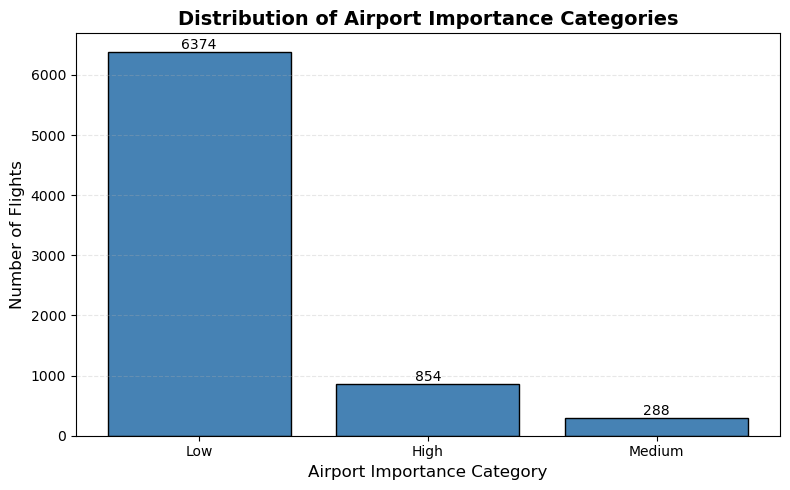

In [18]:
import matplotlib.pyplot as plt

airport_counts = master_df["nearest_airport_importance"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8,5))
bars = plt.bar(airport_counts.index.astype(str),
               airport_counts.values,
               color='steelblue',
               edgecolor='black')

plt.title("Distribution of Airport Importance Categories", fontsize=14, fontweight='bold')
plt.xlabel("Airport Importance Category", fontsize=12)
plt.ylabel("Number of Flights", fontsize=12)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{int(bar.get_height())}',
             ha='center',
             va='bottom',
             fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
master_df["Aircraft_Size_Category"].value_counts()

Aircraft_Size_Category
Narrow-Body          1421
Small Aircraft        918
Regional Aircraft     766
Light Aircraft        698
Wide-Body             664
Name: count, dtype: int64

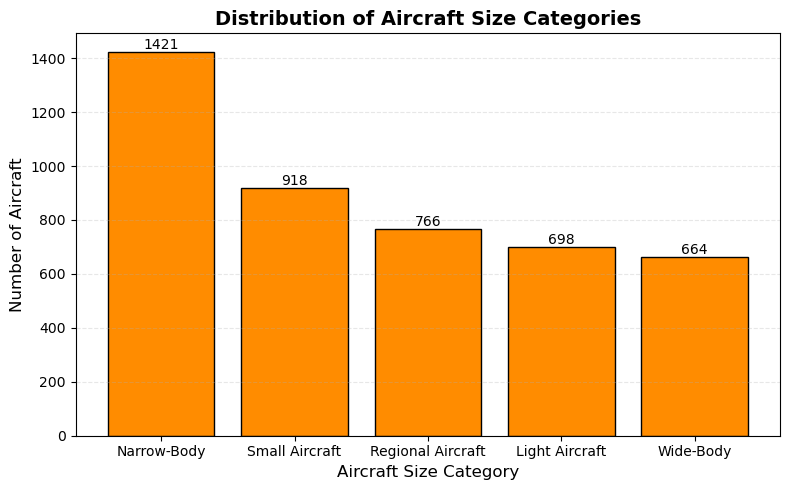

In [20]:
import matplotlib.pyplot as plt

size_counts = master_df["Aircraft_Size_Category"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8,5))
bars = plt.bar(size_counts.index.astype(str),
               size_counts.values,
               color='darkorange',
               edgecolor='black')

plt.title("Distribution of Aircraft Size Categories", fontsize=14, fontweight='bold')
plt.xlabel("Aircraft Size Category", fontsize=12)
plt.ylabel("Number of Aircraft", fontsize=12)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{int(bar.get_height())}',
             ha='center',
             va='bottom',
             fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
master_df["Weight_Category"].value_counts()

Weight_Category
Heavy     3033
Light     1193
Medium     241
Name: count, dtype: int64

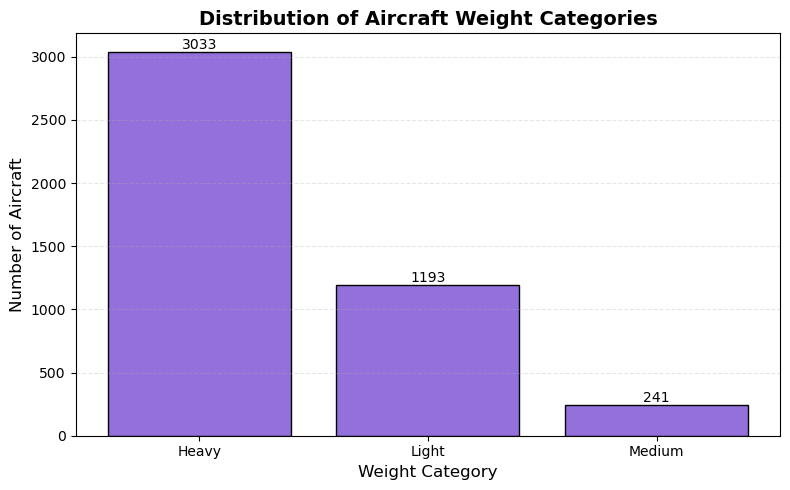

In [22]:
import matplotlib.pyplot as plt

weight_counts = master_df["Weight_Category"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8,5))
bars = plt.bar(weight_counts.index.astype(str),
               weight_counts.values,
               color='mediumpurple',
               edgecolor='black')

plt.title("Distribution of Aircraft Weight Categories", fontsize=14, fontweight='bold')
plt.xlabel("Weight Category", fontsize=12)
plt.ylabel("Number of Aircraft", fontsize=12)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{int(bar.get_height())}',
             ha='center',
             va='bottom',
             fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
master_df["Engine_Configuration"].value_counts()

Engine_Configuration
Twin Engine      3440
Single Engine     985
Three Engine       22
Multi Engine       20
Name: count, dtype: int64

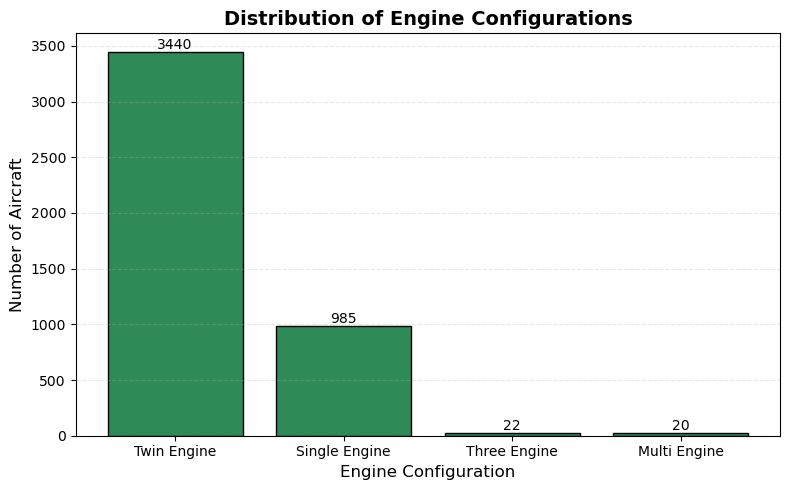

In [24]:
import matplotlib.pyplot as plt

engine_counts = master_df["Engine_Configuration"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8,5))
bars = plt.bar(engine_counts.index.astype(str),
               engine_counts.values,
               color='seagreen',
               edgecolor='black')

plt.title("Distribution of Engine Configurations", fontsize=14, fontweight='bold')
plt.xlabel("Engine Configuration", fontsize=12)
plt.ylabel("Number of Aircraft", fontsize=12)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{int(bar.get_height())}',
             ha='center',
             va='bottom',
             fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
master_df["operational_risk"].value_counts()

operational_risk
Low       6974
Medium     542
Name: count, dtype: int64

In [26]:
master_df["flight_phase"].value_counts()

flight_phase
Cruise     4016
Descent    1739
Climb      1064
Ground      697
Name: count, dtype: int64

In [27]:
# ==========================================================
# Distance Risk Level Feature
# ==========================================================

def distance_risk(distance):
    if distance <= 10:
        return "Very Close"
    elif distance <= 50:
        return "Close"
    elif distance <= 100:
        return "Moderate"
    else:
        return "Remote"

master_df["Distance_Risk_Level"] = master_df["distance_to_airport_km"].apply(distance_risk)

# Check the distribution
master_df["Distance_Risk_Level"].value_counts()

Distance_Risk_Level
Close         3484
Moderate      1834
Very Close    1519
Remote         679
Name: count, dtype: int64

In [28]:
# ==========================================================
# Airport Operational Profile
# ==========================================================

def airport_profile(row):

    # Major commercial airports
    if (row["nearest_airport_importance"] == "High" and
        row["nearest_airport_size"] == "Large"):
        return "Major Hub"

    # Medium commercial airports
    elif (row["nearest_airport_importance"] in ["High", "Medium"] and
          row["nearest_airport_size"] in ["Medium", "Large"]):
        return "Regional Hub"

    # Local airports
    elif row["nearest_airport_importance"] == "Low":
        return "Local Airport"

    # Everything else
    else:
        return "General Airport"


master_df["Airport_Operational_Profile"] = master_df.apply(
    airport_profile,
    axis=1
)

master_df["Airport_Operational_Profile"].value_counts()

Airport_Operational_Profile
Local Airport    6374
Major Hub         854
Regional Hub      288
Name: count, dtype: int64

In [29]:
# ==========================================================
# Aircraft Operational Capability
# ==========================================================
def aircraft_capability(row):

    if pd.isna(row["Aircraft_Size_Category"]):
        return "Unknown"

    # Large commercial aircraft
    if (
        row["Aircraft_Size_Category"] in ["Wide-Body", "Narrow-Body"]
        and row["Engine_Configuration"] == "Twin Engine"
        and row["Weight_Category"] == "Heavy"
    ):
        return "High Capability"

    # Regional aircraft
    elif (
        row["Aircraft_Size_Category"] == "Regional Aircraft"
        and row["Engine_Configuration"] in ["Twin Engine", "Multi Engine"]
    ):
        return "Medium Capability"

    # Small aircraft
    elif row["Aircraft_Size_Category"] in [
        "Small Aircraft",
        "Light Aircraft"
    ]:
        return "Light Capability"

    else:
        return "Standard Capability"


master_df["Aircraft_Operational_Capability"] = master_df.apply(
    aircraft_capability,
    axis=1
)

master_df["Aircraft_Operational_Capability"].value_counts()

Aircraft_Operational_Capability
Unknown                3049
High Capability        2070
Light Capability       1616
Medium Capability       758
Standard Capability      23
Name: count, dtype: int64

In [30]:
# ==========================================================
# Operational Complexity Index
# ==========================================================
complexity_score = {
    "Ground":1,
    "Climb":2,
    "Cruise":2,
    "Descent":3
}

risk_score = {
    "Low":1,
    "Medium":2
}

airport_score = {
    "Local Airport":1,
    "Regional Hub":2,
    "Major Hub":3
}

aircraft_score = {
    "Light Capability":1,
    "Standard Capability":2,
    "Medium Capability":3,
    "High Capability":4,
    "Unknown":2
}

master_df["Operational_Complexity_Index"] = (

    master_df["flight_phase"].map(complexity_score)

    +

    master_df["operational_risk"].map(risk_score)

    +

    master_df["Airport_Operational_Profile"].map(airport_score)

    +

    master_df["Aircraft_Operational_Capability"].map(aircraft_score)

)

In [31]:
def complexity_category(score):

    if score <= 5:
        return "Low"

    elif score <= 8:
        return "Medium"

    else:
        return "High"

master_df["Operational_Complexity_Level"] = (
    master_df["Operational_Complexity_Index"]
    .apply(complexity_category)
)

master_df["Operational_Complexity_Level"].value_counts()

Operational_Complexity_Level
Medium    5505
Low       1104
High       907
Name: count, dtype: int64

In [32]:
def weather_operational_severity(row):

    score = 0

    if row["rain_indicator"] == 1:
        score += 1

    if row["fog_indicator"] == 1:
        score += 1

    if row["snow_indicator"] == 1:
        score += 2

    if row["storm_indicator"] == 1:
        score += 3

    if score <= 1:
        return "Low"

    elif score <= 3:
        return "Medium"

    else:
        return "High"


weather_df["Weather_Operational_Severity"] = weather_df.apply(
    weather_operational_severity,
    axis=1
)

weather_df["Weather_Operational_Severity"].value_counts()

Weather_Operational_Severity
Low       1596466
Medium      30380
High         2262
Name: count, dtype: int64

In [33]:
def weather_disruption(score):

    if score == 1:
        return "Minimal"

    elif score == 2:
        return "Moderate"

    else:
        return "Severe"


weather_df["Weather_Disruption_Level"] = (
    weather_df["weather_risk_score"]
    .apply(weather_disruption)
)

weather_df["Weather_Disruption_Level"].value_counts()

Weather_Disruption_Level
Minimal     1250396
Moderate     364053
Severe        14659
Name: count, dtype: int64

In [34]:
def weather_alert(row):

    if (
        row["Weather_Operational_Severity"] == "High"
        or row["Weather_Disruption_Level"] == "Severe"
    ):
        return "Immediate"

    elif (
        row["Weather_Operational_Severity"] == "Medium"
        or row["Weather_Disruption_Level"] == "Moderate"
    ):
        return "Monitor"

    else:
        return "Routine"


weather_df["Weather_Alert_Priority"] = weather_df.apply(
    weather_alert,
    axis=1
)

weather_df["Weather_Alert_Priority"].value_counts()

Weather_Alert_Priority
Routine      1250396
Monitor       364053
Immediate      14659
Name: count, dtype: int64

In [35]:
# ==========================================================
# Delay Operational Severity
# ==========================================================

def delay_operational_severity(row):

    if (
        row["DELAY_SEVERITY"] == "Severe"
        or row["OPERATIONAL_DISRUPTION"] == 1
    ):
        return "High"

    elif (
        row["DELAY_SEVERITY"] == "Moderate"
        or row["FLIGHT_PERFORMANCE_INDEX"] < 80
    ):
        return "Medium"

    else:
        return "Low"


delay_df["Delay_Operational_Severity"] = delay_df.apply(
    delay_operational_severity,
    axis=1
)

delay_df["Delay_Operational_Severity"].value_counts()

Delay_Operational_Severity
Low       2398515
Medium     340154
High       261331
Name: count, dtype: int64

In [36]:
# ==========================================================
# Airline Reliability Profile
# ==========================================================

def airline_profile(reliability):

    if reliability == "High":
        return "Reliable"

    elif reliability == "Medium":
        return "Average"

    else:
        return "Low Reliability"


delay_df["Airline_Reliability_Profile"] = (
    delay_df["AIRLINE_RELIABILITY"]
    .apply(airline_profile)
)

delay_df["Airline_Reliability_Profile"].value_counts()

Airline_Reliability_Profile
Reliable    1952537
Average     1047463
Name: count, dtype: int64

In [37]:
# ==========================================================
# Delay Alert Priority
# ==========================================================

def delay_priority(row):

    if row["Delay_Operational_Severity"] == "High":
        return "Immediate"

    elif row["Delay_Operational_Severity"] == "Medium":
        return "Monitor"

    else:
        return "Routine"


delay_df["Delay_Alert_Priority"] = delay_df.apply(
    delay_priority,
    axis=1
)

delay_df["Delay_Alert_Priority"].value_counts()

Delay_Alert_Priority
Routine      2398515
Monitor       340154
Immediate     261331
Name: count, dtype: int64

In [38]:
# ==========================================================
# Global Weather Intelligence
# ==========================================================

weather_summary = {
    "Total_Weather_Records": len(weather_df),
    "High_Severity_Percentage":
        round(
            (weather_df["Weather_Operational_Severity"] == "High").mean()*100,
            2
        ),
    "Medium_Severity_Percentage":
        round(
            (weather_df["Weather_Operational_Severity"] == "Medium").mean()*100,
            2
        ),
    "Routine_Weather_Percentage":
        round(
            (weather_df["Weather_Alert_Priority"] == "Routine").mean()*100,
            2
        ),
    "Immediate_Weather_Percentage":
        round(
            (weather_df["Weather_Alert_Priority"] == "Immediate").mean()*100,
            2
        )
}

weather_summary

{'Total_Weather_Records': 1629108,
 'High_Severity_Percentage': np.float64(0.14),
 'Medium_Severity_Percentage': np.float64(1.86),
 'Routine_Weather_Percentage': np.float64(76.75),
 'Immediate_Weather_Percentage': np.float64(0.9)}

In [39]:
# ==========================================================
# Global Delay Intelligence
# ==========================================================

delay_summary = {

    "Total_Delay_Records": len(delay_df),

    "High_Delay_Percentage":
        round(
            (delay_df["Delay_Operational_Severity"]=="High").mean()*100,
            2
        ),

    "Routine_Delay_Percentage":
        round(
            (delay_df["Delay_Alert_Priority"]=="Routine").mean()*100,
            2
        ),

    "Immediate_Delay_Percentage":
        round(
            (delay_df["Delay_Alert_Priority"]=="Immediate").mean()*100,
            2
        ),

    "Reliable_Airline_Percentage":
        round(
            (delay_df["Airline_Reliability_Profile"]=="Reliable").mean()*100,
            2
        )
}

delay_summary

{'Total_Delay_Records': 3000000,
 'High_Delay_Percentage': np.float64(8.71),
 'Routine_Delay_Percentage': np.float64(79.95),
 'Immediate_Delay_Percentage': np.float64(8.71),
 'Reliable_Airline_Percentage': np.float64(65.08)}

In [40]:
# ==========================================================
# Operational Context Summary
# ==========================================================

operational_context = {

    **weather_summary,

    **delay_summary

}

operational_context

{'Total_Weather_Records': 1629108,
 'High_Severity_Percentage': np.float64(0.14),
 'Medium_Severity_Percentage': np.float64(1.86),
 'Routine_Weather_Percentage': np.float64(76.75),
 'Immediate_Weather_Percentage': np.float64(0.9),
 'Total_Delay_Records': 3000000,
 'High_Delay_Percentage': np.float64(8.71),
 'Routine_Delay_Percentage': np.float64(79.95),
 'Immediate_Delay_Percentage': np.float64(8.71),
 'Reliable_Airline_Percentage': np.float64(65.08)}

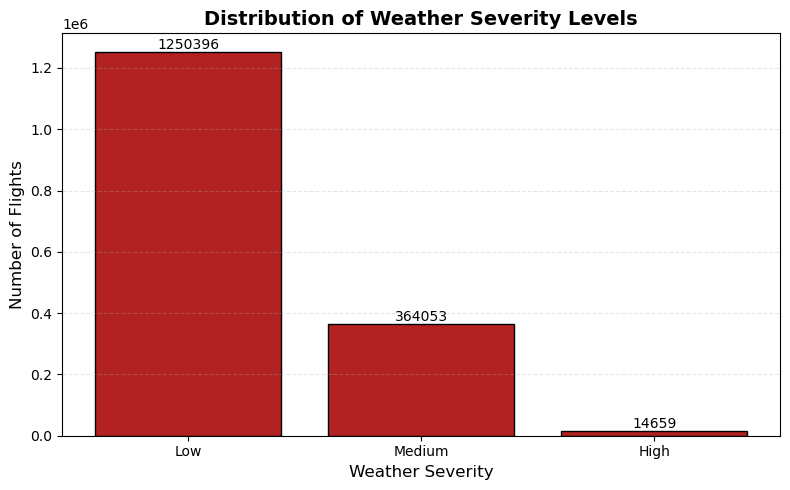

In [42]:
import matplotlib.pyplot as plt

weather_counts = weather_df["weather_severity"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8,5))
bars = plt.bar(weather_counts.index.astype(str),
               weather_counts.values,
               color='firebrick',
               edgecolor='black')

plt.title("Distribution of Weather Severity Levels", fontsize=14, fontweight='bold')
plt.xlabel("Weather Severity", fontsize=12)
plt.ylabel("Number of Flights", fontsize=12)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{int(bar.get_height())}',
             ha='center',
             va='bottom',
             fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

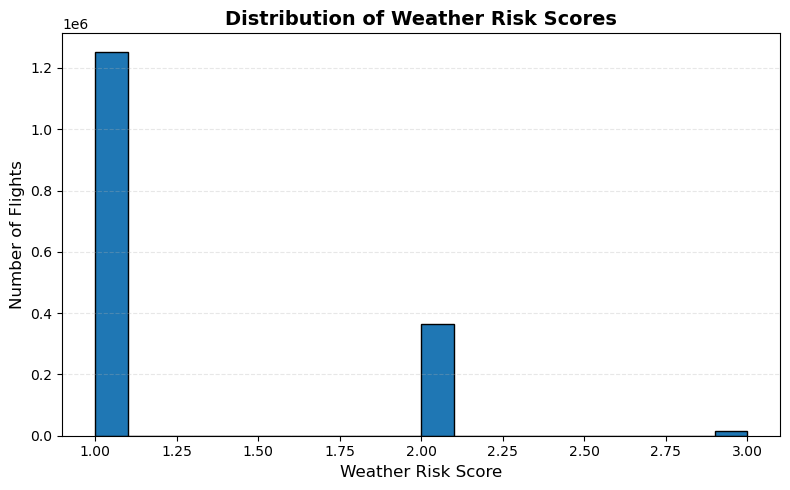

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(weather_df["weather_risk_score"].dropna(),
         bins=20,
         edgecolor='black')

plt.title("Distribution of Weather Risk Scores", fontsize=14, fontweight='bold')
plt.xlabel("Weather Risk Score", fontsize=12)
plt.ylabel("Number of Flights", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
weather_df.to_csv(
    "../data/final/weather_cross_dataset_feature_engineered.csv",
    index=False
)

delay_df.to_csv(
    "../data/final/delay_cross_dataset_feature_engineered.csv",
    index=False
)

master_df.to_csv(
    "../data/final/flight_operations_cross_dataset_feature_engineered.csv",
    index=False
)

print("Cross-Dataset Feature Engineering Completed Successfully!")